In [1]:
import matplotlib.pyplot as plt
import pickle

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
with open('../output/pinaw-qrf-steps-cog.npy', 'rb+') as f:
    pinaws_cog = pickle.load(f)
with open('../output/pinaw-qrf-steps-dif.npy', 'rb+') as f:
    pinaws_dif = pickle.load(f)[25:]

In [3]:
with open('../output/picp-qrf-steps-cog.npy', 'rb+') as f:
    picps_cog = pickle.load(f)
with open('../output/picp-qrf-steps-dif.npy', 'rb+') as f:
    picps_dif = pickle.load(f)[25:]

In [7]:
picps_cog[0]

np.float64(0.9542272482498654)

In [9]:
pinaws_dif[0]

np.float64(0.0013317721380662836)

In [8]:
pinaws_cog[0]

np.float64(0.0013522563668494773)

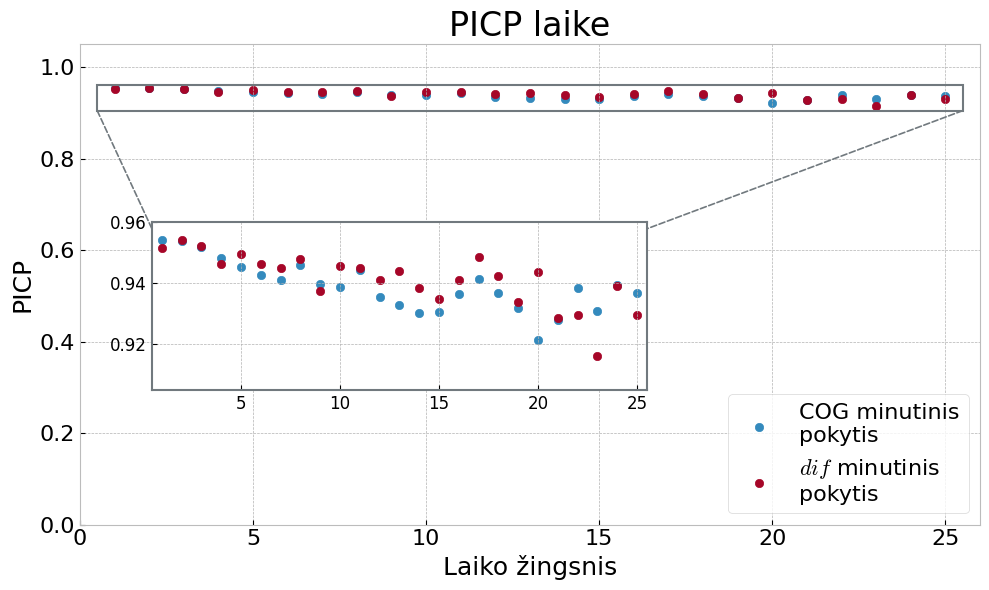

In [4]:
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(range(1, 26), picps_cog, label='COG minutinis\npokytis')
ax.scatter(range(1, 26), picps_dif, label='$dif$ minutinis\npokytis')
ax.set_ylim((0, 1.05))
ax.set_xlim((0, 26))

# Rectangle border around the region of interest
rect = mpatches.Rectangle(
    (0.5, 0.905),
    25.0,
    0.055,
    linewidth=1.5,
    edgecolor='#71797E',
    facecolor='none',
    zorder=5
)
ax.add_patch(rect)

# ── Inset axes ────────────────────────────────────────────────────────────────
axins = ax.inset_axes([0.08, 0.28, 0.55, 0.35])
axins.scatter(range(1, 26), picps_cog)
axins.scatter(range(1, 26), picps_dif)
axins.set_xlim(0.5, 25.5)
axins.set_ylim(0.905, 0.96)
axins.set_xlabel('', fontsize=12)
axins.tick_params(labelsize=12)          # was 7
axins.set_facecolor('white')
for spine in axins.spines.values():
    spine.set_edgecolor('#71797E')
    spine.set_linewidth(1.5)

# ── Connection lines ──────────────────────────────────────────────────────────
con_left = ConnectionPatch(
    xyA=(0.5, 0.905), coordsA=ax.transData,
    xyB=(0, 0.96),      coordsB=axins.transAxes,
    color='#71797E', linewidth=1.2, linestyle='--'
)
con_right = ConnectionPatch(
    xyA=(25.5, 0.905), coordsA=ax.transData,
    xyB=(1, 0.96),        coordsB=axins.transAxes,
    color='#71797E', linewidth=1.2, linestyle='--'
)
fig.add_artist(con_left)
fig.add_artist(con_right)

ax.legend(loc='lower right', fontsize=16)          # added fontsize
ax.set_xlabel('Laiko žingsnis', fontsize=18)        # added fontsize
ax.set_ylabel('PICP', fontsize=18)                  # added fontsize
ax.set_title('PICP laike', fontsize=24)             # added fontsize
ax.tick_params(labelsize=16)                        # added for axis tick labels

plt.tight_layout()
plt.savefig('picp_with_inset-qrf.png', dpi=750)
plt.show()

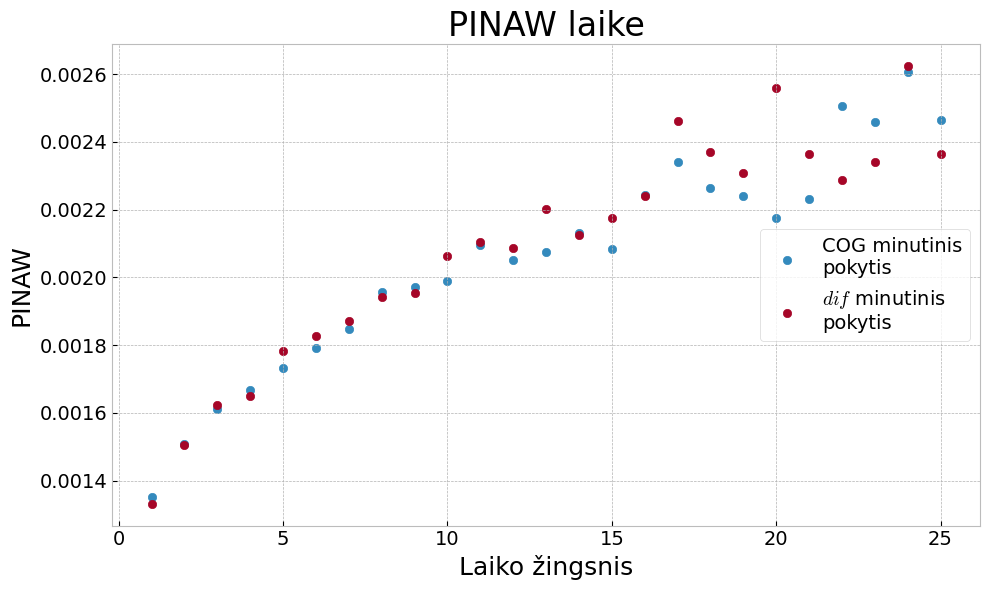

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

plt.scatter(range(1, 26), pinaws_cog, label='COG minutinis\npokytis')
plt.scatter(range(1, 26), pinaws_dif, label='$dif$ minutinis\npokytis')

plt.title('PINAW laike', size=24)
plt.xlabel('Laiko žingsnis', fontdict={'size':18})
plt.ylabel('PINAW', fontdict={'size':18})
plt.tick_params(axis='both', labelsize=14)

plt.legend(loc='center right', fontsize=14)


plt.tight_layout()
plt.savefig('pinaw_qrf.png', dpi=750)
plt.show()